# Paper figures

## imports

In [119]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from figutils import cm, set_figure_style

set_figure_style()

PAL_MODALITIES = {
    "rna_seq":          "#717EC3",
    "splice_site":      "#AE8799",
    "splice_usage":     "#C95D63",
    "splice_junctions": "#EE8434",
}

PAL_SAMPLES = {
    "WT":    "#C5CBD3",
    "K700E": "#8D6A9F",
}

In [120]:
def plot_pearson_bars(data, title, outfile, ylabel="Pearson r"):
    col_order    = [SUBSET_LABELS[s] for s in SUBSETS]
    sample_order = list(SAMPLE_LABELS.values())
    has_n = "n" in data.columns

    g = sns.catplot(
        data=data,
        kind="bar",
        x="sample", y="pearson_r",
        col="subset_label",
        col_order=col_order,
        order=sample_order,
        palette=PAL_SAMPLES,
        width=0.6,
        height=4 * cm,
        aspect=0.6,
    )
    g.set_axis_labels("", ylabel)
    g.set_titles("{col_name}")
    g.set(ylim=(0, 1.05))
    for ax in g.axes.flat:
        subset_label = ax.get_title()
        for bar_idx, bar in enumerate(ax.patches):
            sample = sample_order[bar_idx]
            h = bar.get_height()
            cx = bar.get_x() + bar.get_width() / 2
            # Pearson r above bar
            ax.text(cx, h + 0.02, "{:.2f}".format(h),
                    ha="center", va="bottom", fontsize=6)
            # n= rotated vertically at the bottom of the bar
            if has_n:
                row = data[
                    (data["subset_label"] == subset_label) & (data["sample"] == sample)
                ]
                n = int(row["n"].values[0])
                ax.text(cx, 0.02, "n={:,}".format(n),
                        ha="center", va="bottom", fontsize=5,
                        rotation=90, color="white")
    g.figure.suptitle(title, y=1.04)
    plt.tight_layout()
    g.figure.savefig(outfile, bbox_inches="tight")
    plt.show()
    print("saved:", outfile)

## data

In [121]:
ROOT     = ".."
EVAL_DIR = os.path.join(ROOT, "results", "bsc", "evaluation", "alphagenome_pytorch", "full")

OUTPUT_DIR = os.path.join("pdfs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

RUN_NAME  = "randinit__newloss__annotated__frozen__multigpu_ddp"
EPOCH     = 10
SUBSETS   = ["test", "train_sample"]

SAMPLE_LABELS = {
    "SRR17111303": "WT",
    "SRR17111311": "K700E",
}

SUBSET_LABELS = {
    "test":         "Test intervals",
    "train_sample": "Train sample",
}

In [122]:
records = []
for subset in SUBSETS:
    pred_dir = os.path.join(EVAL_DIR, RUN_NAME, "epoch{}".format(EPOCH), subset, "predictions")
    metrics_df = pd.read_parquet(os.path.join(EVAL_DIR, RUN_NAME, "epoch{}".format(EPOCH), subset, "metrics.parquet"))
    rna_df     = pd.read_parquet(os.path.join(pred_dir, "rna_seq_per_gene.parquet"))
    for sample_id, sample_label in SAMPLE_LABELS.items():
        r = float(metrics_df.loc[metrics_df["metric_name"] == "gene_expr_raw_track_{}".format(sample_id), "value"].values[0])
        n = int((rna_df["track_name"] == sample_id).sum())
        records.append({"subset": subset, "sample": sample_label, "pearson_r": r, "n": n})

metrics = pd.DataFrame(records)
metrics["subset_label"] = metrics["subset"].map(SUBSET_LABELS)
print(metrics)

         subset sample  pearson_r      n    subset_label
0          test     WT   0.901071   6631  Test intervals
1          test  K700E   0.897334   6631  Test intervals
2  train_sample     WT   0.958537  46092    Train sample
3  train_sample  K700E   0.953478  46092    Train sample


## figures

### gene expression — Pearson r by sample, faceted by interval subset

/tmp/ipykernel_3905523/2901933246.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


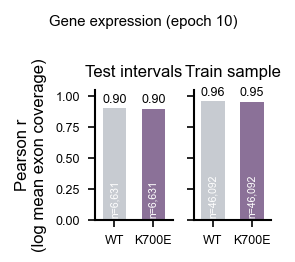

saved: pdfs/gene_expr_pearson_epoch10.pdf


In [123]:
plot_pearson_bars(
    data=metrics,
    title="Gene expression (epoch {})".format(EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "gene_expr_pearson_epoch{}.pdf".format(EPOCH)),
    ylabel="Pearson r\n(log mean exon coverage)",
)

### splice site usage (SSU) — Pearson r by sample, faceted by interval subset

In [124]:
records = []
for subset in SUBSETS:
    fpath = os.path.join(EVAL_DIR, RUN_NAME, "epoch{}".format(EPOCH), subset, "predictions", "ssu_scores.parquet")
    df = pd.read_parquet(fpath)
    for sample_id, sample_label in SAMPLE_LABELS.items():
        grp = df[df["sample_id"] == sample_id]
        r, _ = stats.pearsonr(grp["pred_ssu"].values, grp["obs_ssu"].values)
        records.append({"subset": subset, "sample": sample_label, "pearson_r": float(r), "n": len(grp)})

ssu_metrics = pd.DataFrame(records)
ssu_metrics["subset_label"] = ssu_metrics["subset"].map(SUBSET_LABELS)
print(ssu_metrics)

         subset sample  pearson_r       n    subset_label
0          test     WT   0.713447  813658  Test intervals
1          test  K700E   0.578977  879027  Test intervals
2  train_sample     WT   0.760640  910722    Train sample
3  train_sample  K700E   0.650514  983404    Train sample


/tmp/ipykernel_3905523/2901933246.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


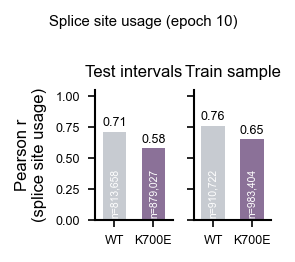

saved: pdfs/ssu_pearson_epoch10.pdf


In [125]:
plot_pearson_bars(
    data=ssu_metrics,
    title="Splice site usage (epoch {})".format(EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "ssu_pearson_epoch{}.pdf".format(EPOCH)),
    ylabel="Pearson r\n(splice site usage)",
)

### SSU — Pangolin test intervals (unseen chromosomes)

In [128]:
PANGOLIN_UNSEEN_CHROMS = {"chr1", "chr3", "chr5", "chr7", "chr9"}

records = []
for subset in SUBSETS:
    fpath = os.path.join(EVAL_DIR, RUN_NAME, "epoch{}".format(EPOCH), subset, "predictions", "ssu_scores.parquet")
    df = pd.read_parquet(fpath)
    df_unseen = df[df["chrom"].isin(PANGOLIN_UNSEEN_CHROMS)]
    for sample_id, sample_label in SAMPLE_LABELS.items():
        grp = df_unseen[df_unseen["sample_id"] == sample_id]
        r, _ = stats.pearsonr(grp["pred_ssu"].values, grp["obs_ssu"].values)
        records.append({"subset": subset, "sample": sample_label, "pearson_r": float(r), "n": len(grp)})

ssu_pangolin_metrics = pd.DataFrame(records)
ssu_pangolin_metrics["subset_label"] = ssu_pangolin_metrics["subset"].map(SUBSET_LABELS)
print(ssu_pangolin_metrics)

         subset sample  pearson_r       n    subset_label
0          test     WT   0.747620  189724  Test intervals
1          test  K700E   0.630729  204761  Test intervals
2  train_sample     WT   0.758452  265890    Train sample
3  train_sample  K700E   0.645519  288702    Train sample


/tmp/ipykernel_3905523/2901933246.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


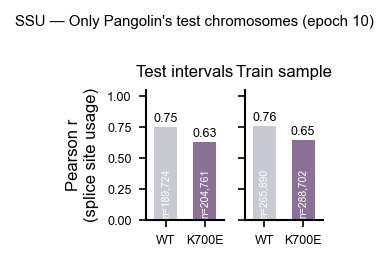

saved: pdfs/ssu_pearson_pangolin_unseen_epoch10.pdf


In [130]:
plot_pearson_bars(
    data=ssu_pangolin_metrics,
    title="SSU — Only Pangolin's test chromosomes (epoch {})".format(EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "ssu_pearson_pangolin_unseen_epoch{}.pdf".format(EPOCH)),
    ylabel="Pearson r\n(splice site usage)",
)

### junction counts — Pearson r by sample, faceted by interval subset

In [126]:
records = []
for subset in SUBSETS:
    pred_dir   = os.path.join(EVAL_DIR, RUN_NAME, "epoch{}".format(EPOCH), subset, "predictions")
    metrics_df = pd.read_parquet(os.path.join(EVAL_DIR, RUN_NAME, "epoch{}".format(EPOCH), subset, "metrics.parquet"))
    junc_df    = pd.read_parquet(os.path.join(pred_dir, "junction_scores.parquet"))
    for sample_id, sample_label in SAMPLE_LABELS.items():
        r = float(metrics_df.loc[metrics_df["metric_name"] == "junction_count_pearson_r_{}".format(sample_id), "value"].values[0])
        n = int(((junc_df["sample_id"] == sample_id) & (junc_df["obs_count"] > 0)).sum())
        records.append({"subset": subset, "sample": sample_label, "pearson_r": r, "n": n})

junc_metrics = pd.DataFrame(records)
junc_metrics["subset_label"] = junc_metrics["subset"].map(SUBSET_LABELS)
print(junc_metrics)

         subset sample  pearson_r       n    subset_label
0          test     WT   0.784472  587974  Test intervals
1          test  K700E   0.791204  641729  Test intervals
2  train_sample     WT   0.879412  656552    Train sample
3  train_sample  K700E   0.879419  717582    Train sample


/tmp/ipykernel_3905523/2901933246.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


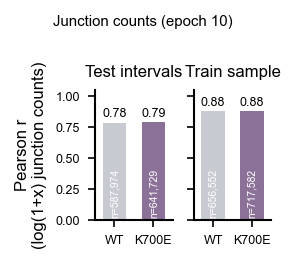

saved: pdfs/junction_count_pearson_epoch10.pdf


In [127]:
plot_pearson_bars(
    data=junc_metrics,
    title="Junction counts (epoch {})".format(EPOCH),
    outfile=os.path.join(OUTPUT_DIR, "junction_count_pearson_epoch{}.pdf".format(EPOCH)),
    ylabel="Pearson r\n(log(1+x) junction counts)",
)